In [66]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

aq = pd.read_csv("air_quality.csv") # air quality
gps = pd.read_csv("gps.csv") # location
pth = pd.read_csv("pth.csv") # pressure, temp, humidity
rad = pd.read_csv("radiation.csv") # radiation
spect = pd.read_csv("spectrum.csv") # spectrum

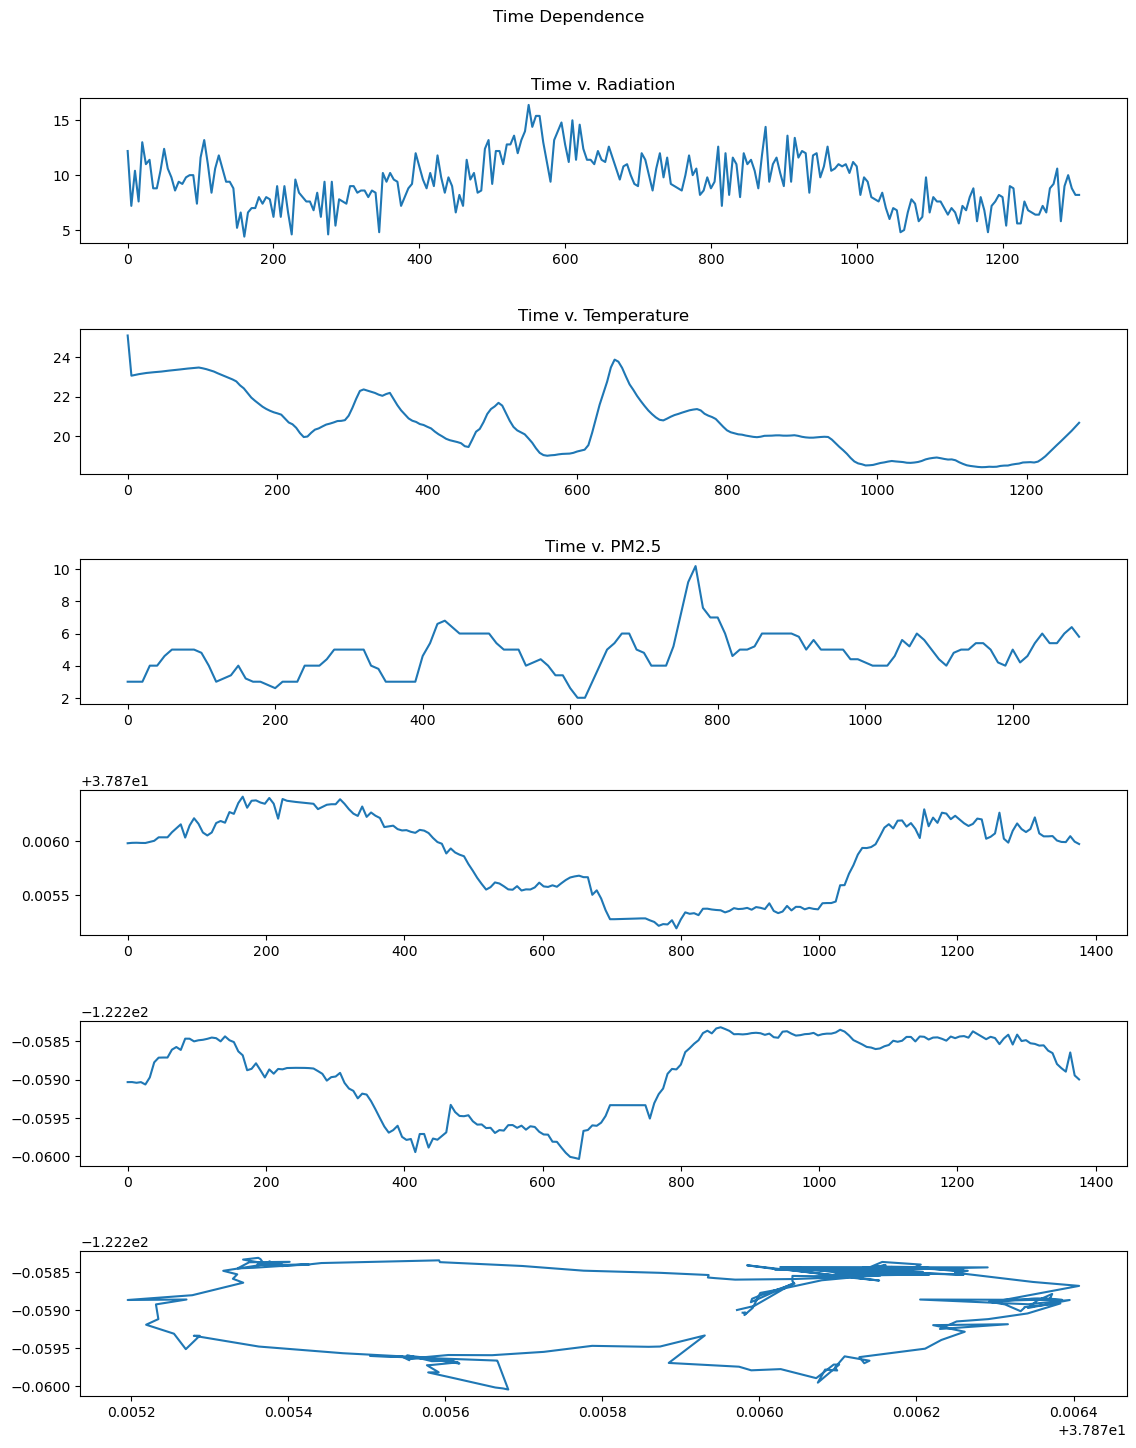

In [67]:
# QUESTION 26:
fig, ax = plt.subplots(6)
fig.set_figheight(15)
fig.set_figwidth(12)
fig.suptitle("Time Dependence")

radvt = ax[0].plot(np.arange(0, 5 * len(rad), 5), rad["cps"]) # radiation, time dependent
ax[0].set_title("Time v. Radiation")
# note: gps data starts at point 17 of the radiation data for some reason.
# radvp = ax[1].plot(np.) # radiation, position dependent ()

tempvt = ax[1].plot(np.arange(0, 5 * len(pth), 5), pth["temp_mean"])
ax[1].set_title("Time v. Temperature")

pm25vt = ax[2].plot(np.arange(0, 10 * len(aq), 10), aq["pm25_mean"])
ax[2].set_title("Time v. PM2.5")

latvt = ax[3].plot(np.arange(0, 6.4 * len(gps), 6.4), gps["latitude"])
longvt = ax[4].plot(np.arange(0, 6.4 * len(gps), 6.4), gps["longitude"])

latvlong = ax[5].plot(gps["latitude"], gps["longitude"])

plt.tight_layout(pad=3.0)

Radiation and PM2.5 Concentration data seem to follow a normal distribution, but not the temperature data.
This is probably because the temperature varies much more widely between different locations than it does in one location.
As a result, the smaller variations that would constitute a normal distribution are drowned out by these larger shifts.


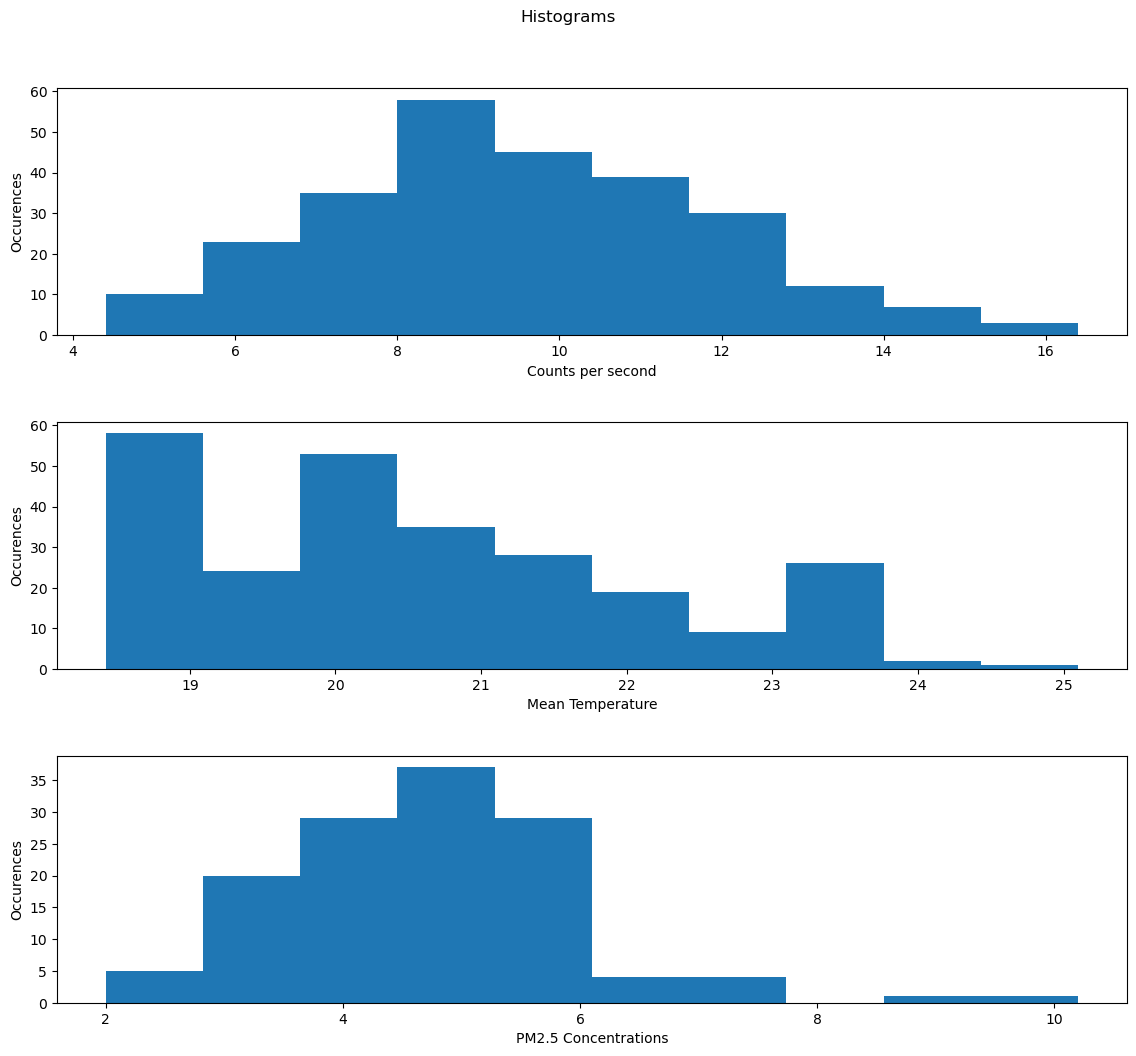

In [84]:
# Histograms!
fig, ax = plt.subplots(3)
fig.set_figheight(11)
fig.set_figwidth(12)
fig.suptitle("Histograms")

ax[0].hist(rad["cps"])
ax[0].set_ylabel("Occurences")
ax[0].set_xlabel("Counts per second")

ax[1].hist(pth["temp_mean"])
ax[1].set_ylabel("Occurences")
ax[1].set_xlabel("Mean Temperature")

ax[2].hist(aq["pm25_mean"])
ax[2].set_ylabel("Occurences")
ax[2].set_xlabel("PM2.5 Concentrations")

print("Radiation and PM2.5 Concentration data seem to follow a normal distribution, but not the temperature data.")
print("This is probably because the temperature varies much more widely between different locations than it does in one location.")
print("As a result, the smaller variations that would constitute a normal distribution are drowned out by these larger shifts.")
plt.tight_layout(pad=3.0)

In [69]:
# Radiation Counts and Variance
# first, find mean of full data set.
totalcounts = np.sum(rad["cps"])
rad_mean = totalcounts / len(rad)
print("Mean of full dataset: " + str(exp_mean))
# expected standard deviation:
exp_dev = np.sqrt(rad_mean)
print("Expected standard deviation: " + str(exp_dev))
# measured standard deviation (mean of errors)
totalerror = np.sum(rad["cps_err"])
err_mean = totalerror / len(rad)
print("Measured standard deviation: " + str(err_mean))
print("The measured standard deviation was much lower than was predicted through counting statistics.")

Mean of full dataset: 9.432061068702291
Expected standard deviation: 3.0711660763791806
Measured standard deviation: 1.3627231614296567
The measured standard deviation was much lower than was predicted through counting statistics.


In [70]:
# Question 29: Testing statistical agreement
# finding uncertainty on measured standard deviation.
meas_unc = err_mean / np.sqrt(2*len(rad))
print("Uncertainty on measured standard deviation: " + str(meas_unc))

Uncertainty on measured standard deviation: 0.05953083771235227


In [71]:
# Question 30: interpretation of data
print("From the estimate of the expected variance and the uncertainty on the measured variance, we can conclude that the measured data had significantly less variance than what was expected.")
print("This is likely due to the fact that we don't know how the detector itself measures its error.")
print("It seems like the detector's error is a square root of the cps divided by the square root of 5.")
print("This way of counting error may have to do with expectations surrounding the detector, such as the likelihood of skipped counts during a deadzone, but provides different results than the standard calculation.")

From the estimate of the expected variance and the uncertainty on the measured variance, we can conclude that the measured data had significantly less variance than what was expected.
This is likely due to the fact that we don't know how the detector itself measures its error.
It seems like the detector's error is a square root of the cps divided by the square root of 5.
This way of counting error may have to do with expectations surrounding the detector, such as the likelihood of skipped counts during a deadzone, but provides different results than the standard calculation.


235


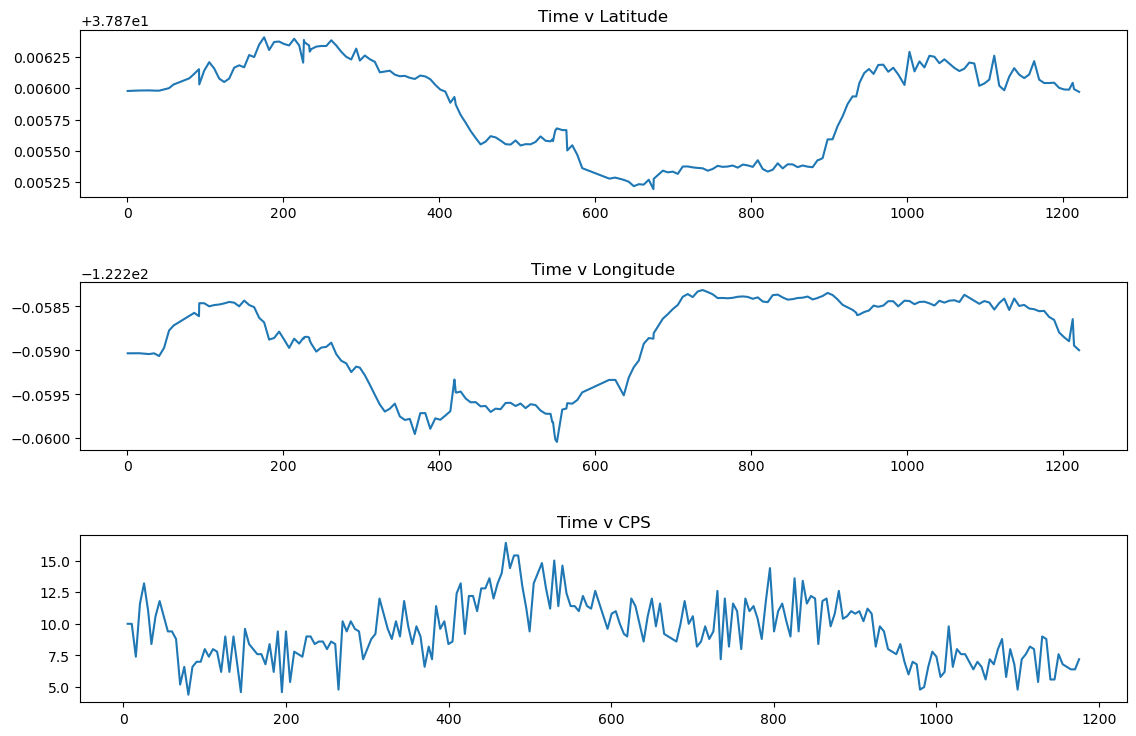

In [92]:
# Question 31.... estimated mean counts per location...

# ok. One significant hurdle for this part is that the gps data is not recorded in intervals of 5, or even 10, but instead a value near 6.4. ???
# Also it starts at a different time than our radiation data. -.-
# ok enough complaining.

# THING ONE: slicing the data properly
# gps data starts at timestamp 1776470679, ends at 1776471900; rad data will be sliced accordingly.
# pandas uses "loc" and "iloc" for slicing:
sliced_rad = rad.iloc[17:252, :]
print(len(sliced_rad))

# THING TWO: changing timescale into something readable
readable_gps = gps.copy()
readable_rad = sliced_rad.copy()
readable_gps.iloc[:, 0:1] = gps.iloc[:, 0:1] - 1776470679
readable_rad.iloc[:, 0:1] = sliced_rad.iloc[:, 0:1] - 1776470679

# THING THREE: plotting latitude, longitude, and radiation
fig, ax = plt.subplots(3)
fig.set_figheight(8)
fig.set_figwidth(12)

timelat = ax[0].plot(readable_gps["timestamp"], readable_gps["latitude"])
ax[0].set_title("Time v Latitude")
timelong = ax[1].plot(readable_gps["timestamp"], readable_gps["longitude"])
ax[1].set_title("Time v Longitude")
timerad = ax[2].plot(readable_rad["timestamp"], readable_rad["cps"])
ax[2].set_title("Time v CPS")
plt.tight_layout(pad=3.0)

In [118]:
# Based on the above data, we can isolate different "zones;" e.g., locations of relatively static longitude or latitude.
# Latitude is static from ~100-400, ~400-600, ~600-900, and ~950-end
# Longitude is static from ~0-200, ~400-600, and ~700-end
# Based on this, we can argue for four different locations: 950-end, 700-900, 400-600, 100-200

# LOCATION ONE: T=100 - T=200
rad_loc1 = readable_rad[readable_rad["timestamp"] > 100]
rad_loc1 = rad_loc1[rad_loc1["timestamp"] < 200]
rad1mean = np.sum(rad_loc1["cps"]) / len(rad_loc1)
print("Mean of counts at location one: " + str(rad1mean))
# finding uncertainty:
rad1unc = np.sqrt(rad1mean)
print("Uncertainty on the mean: " + str(rad1unc))

# LOCATION TWO: T=400 - T=600
rad_loc2 = readable_rad[readable_rad["timestamp"] > 400]
rad_loc2 = rad_loc2[rad_loc2["timestamp"] < 600]
rad2mean = np.sum(rad_loc2["cps"]) / len(rad_loc2)
print("Mean of counts at location two: " + str(rad2mean))
rad2unc = np.sqrt(rad2mean)
print("Uncertainty on the mean: " + str(rad2unc))

# LOCATION THREE: T=700 - T=900
rad_loc3 = readable_rad[readable_rad["timestamp"] > 700]
rad_loc3 = rad_loc3[rad_loc3["timestamp"] < 900]
rad3mean = np.sum(rad_loc3["cps"]) / len(rad_loc3)
print("Mean of counts at location three: " + str(rad3mean))
rad3unc = np.sqrt(rad3mean)
print("Uncertainty on the mean: " + str(rad3unc))

# LOCATION FOUR: T=950 - T=end
rad_loc4 = readable_rad[readable_rad["timestamp"] > 950]
rad4mean = np.sum(rad_loc4["cps"]) / len(rad_loc4)
print("Mean of counts at location four: " + str(rad4mean))
rad4unc = np.sqrt(rad4mean)
print("Uncertainty on the mean: " + str(rad4unc))

Mean of counts at location one: 7.561904761904763
Uncertainty on the mean: 2.749891772762114
Mean of counts at location two: 12.430769230769231
Uncertainty on the mean: 3.525729602616915
Mean of counts at location three: 10.665000000000001
Uncertainty on the mean: 3.2657311585615862
Mean of counts at location four: 6.982608695652175
Uncertainty on the mean: 2.6424626195373464


In [122]:
print("Locations one and four had a similar amount of counts, as did two and three, which were within one standard deviation of each other.")
print("However, there was definitely a difference between these two groups, which we can see by comparing locations four and two.")
unc2_4 = np.sqrt(rad2unc**2 + rad4unc**2) # adding in quadrature
sdapart = (rad2mean - rad4mean) / unc2_4
print("Locations 2 and 4 were " + str(sdapart) + " uncertanties apart.")
print("Even still, this is not a very significant difference, as a little over 68% of the values in a normal distribution will fall within this range.")
print("As a result, these differences are also not practically significant.")

Locations one and four had a similar amount of counts, as did two and three, which were within one standard deviation of each other.
However, there was definitely a difference between these two groups, which we can see by comparing locations four and two.
Locations 2 and 4 were 1.2365148641870944 uncertanties apart.
Even still, this is not a very significant difference, as a little over 68% of the values in a normal distribution will fall within this range.
As a result, these differences are also not practically significant.
